Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Best Parameters for XGBoost: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}
[LightGBM] [Info] Number of positive: 337, number of negative: 337
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000239 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1095
[LightGBM] [Info] Number of data points in the train set: 674, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posi

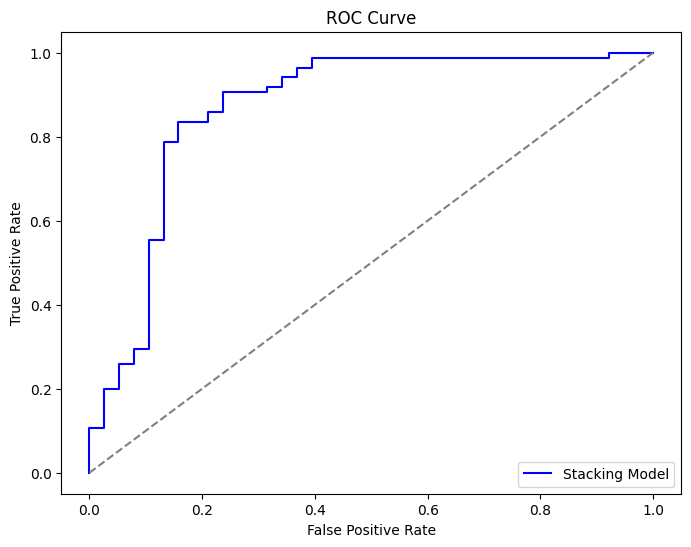

Model saved as stacking_loan_model.pkl


In [ ]:
# Step 1: Install required libraries (if not already installed)
!pip install catboost xgboost lightgbm imbalanced-learn keras joblib

# Step 2: Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import StackingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, roc_auc_score
from imblearn.over_sampling import SMOTE
import catboost
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
from keras.models import Sequential
from keras.layers import Dense
import joblib

# Load the dataset
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Path to your dataset in Google Drive
file_path = '/content/drive/MyDrive/Dataset/dataset.csv'

# Load the dataset
df = pd.read_csv(file_path)



# Step 4: Drop unnecessary columns
df.drop('Loan_ID', axis=1, inplace=True)

from sklearn.preprocessing import LabelEncoder

# Step 5: Improved Feature Engineering and Handle Missing Values

# 5.1: Total Income (ApplicantIncome + CoapplicantIncome)
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']

# 5.2: Loan-to-Income Ratio (LoanAmount / TotalIncome)
df['LoanToIncomeRatio'] = df['LoanAmount'] / df['TotalIncome']

# 5.3: Binning the 'LoanAmount' for better interpretation
df['LoanAmountBin'] = pd.cut(df['LoanAmount'], bins=[0, 100, 200, 300, 400, np.inf], labels=['Low', 'Medium', 'High', 'Very High', 'Extreme'])

# 5.4: Handle missing values
for col in df.columns:
    if df[col].dtype == 'object' or df[col].dtype.name == 'category':
        df[col] = df[col].astype(str)  # Convert categorical columns to string
        df[col] = df[col].fillna(df[col].mode()[0])  # Fill categorical columns with mode
    else:
        df[col] = df[col].fillna(df[col].median())  # Fill numerical columns with median

# Step 6: Encode categorical features using Label Encoding
label_encoder = LabelEncoder()

# Apply Label Encoding to categorical columns
cat_features = X.select_dtypes(include='object').columns.tolist()  # List of categorical columns
for col in cat_features:
    df[col] = label_encoder.fit_transform(df[col])  # Transform the column

# Step 7: Encode target variable (Loan_Status)
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

# Step 8: Split the data into features and target
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

# Step 9: Stratified Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Step 10: Handle class imbalance using SMOTE (Synthetic Minority Over-sampling Technique)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)



# Step 11: Model Initialization (XGBoost, LightGBM, and CatBoost)

# CatBoost Model
catboost_model = CatBoostClassifier(iterations=500, learning_rate=0.05, depth=6, cat_features=cat_features, loss_function='Logloss', eval_metric='AUC', early_stopping_rounds=30, random_seed=42, verbose=0)

# XGBoost Model
xgb_model = XGBClassifier(random_state=42, scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1]))

# LightGBM Model
lgb_model = lgb.LGBMClassifier(random_state=42, scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1]))

# Step 12: Hyperparameter Tuning using GridSearchCV (Optional)
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 200, 500]
}

grid_search = GridSearchCV(XGBClassifier(), param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)
print("Best Parameters for XGBoost:", grid_search.best_params_)

# Step 13: Ensemble Methods (Stacking and Voting)
# Define the base models for stacking
base_learners = [
    ('xgb', xgb_model),
    ('lgbm', lgb_model),
    ('catboost', catboost_model)
]

# Meta-model (Logistic Regression)
meta_model = LogisticRegression()

# Stacking model
stacking_model = StackingClassifier(estimators=base_learners, final_estimator=meta_model)

# Train the stacking model
stacking_model.fit(X_train_smote, y_train_smote)

# Voting Classifier (Soft Voting)
voting_model = VotingClassifier(estimators=[('xgb', xgb_model), ('lgbm', lgb_model), ('catboost', catboost_model)], voting='soft')
voting_model.fit(X_train_smote, y_train_smote)

# Step 14: Evaluate the Models
models = {'Stacking Model': stacking_model, 'Voting Classifier': voting_model}

for model_name, model in models.items():
    print(f"Evaluating {model_name}...")
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("ROC AUC:", roc_auc_score(y_test, y_proba))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Step 15: Plot ROC AUC for Stacking Model
from sklearn.metrics import roc_curve

y_pred_prob = stacking_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label="Stacking Model")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc='lower right')
plt.show()

# Step 16: Save the Stacking Model
joblib.dump(stacking_model, 'stacking_loan_model.pkl')
print("Model saved as stacking_loan_model.pkl")


Best Parameters for XGBoost: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}
[LightGBM] [Info] Number of positive: 337, number of negative: 154
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000157 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 709
[LightGBM] [Info] Number of data points in the train set: 491, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.686354 -> initscore=0.783130
[LightGBM] [Info] Start training from score 0.783130
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

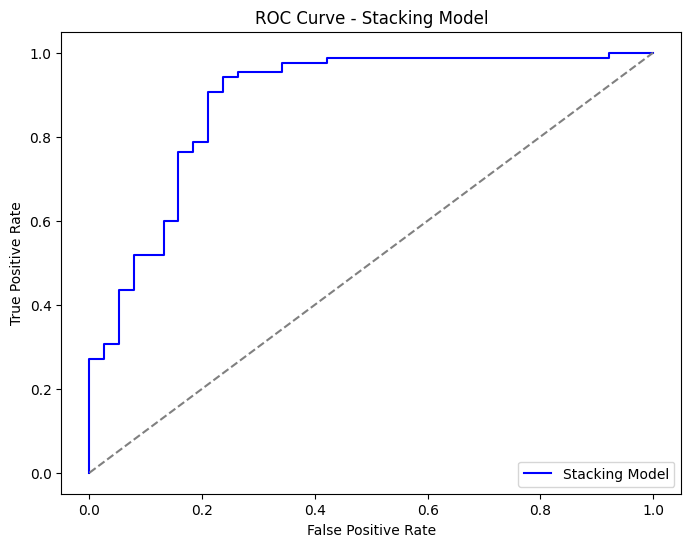

Tuned Model saved as stacking_loan_model_tuned.pkl


In [ ]:
# Step 10: Hyperparameter Tuning with GridSearchCV (Example for XGBoost)
from sklearn.model_selection import GridSearchCV

# Define hyperparameter grid for XGBoost
param_grid_xgb = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 200, 500]
}

# Grid search for XGBoost
grid_search_xgb = GridSearchCV(XGBClassifier(random_state=42), param_grid_xgb, cv=3, scoring='accuracy', n_jobs=-1)
grid_search_xgb.fit(X_train, y_train)
print("Best Parameters for XGBoost:", grid_search_xgb.best_params_)

# Step 11: Hyperparameter Tuning for LightGBM (Example)
param_grid_lgb = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 200, 500]
}

grid_search_lgb = GridSearchCV(lgb.LGBMClassifier(random_state=42), param_grid_lgb, cv=3, scoring='accuracy', n_jobs=-1)
grid_search_lgb.fit(X_train, y_train)
print("Best Parameters for LightGBM:", grid_search_lgb.best_params_)

# Step 12: Hyperparameter Tuning for CatBoost (Example)
param_grid_catboost = {
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [4, 6, 8],
    'iterations': [100, 200, 500]
}

grid_search_catboost = GridSearchCV(CatBoostClassifier(loss_function='Logloss', eval_metric='AUC', random_seed=42, verbose=0), param_grid_catboost, cv=3, scoring='accuracy', n_jobs=-1)
grid_search_catboost.fit(X_train, y_train)
print("Best Parameters for CatBoost:", grid_search_catboost.best_params_)

# Step 13: Model Ensembling - Stacking Classifier
# Using tuned modelsh
best_xgb_model = grid_search_xgb.best_estimator_
best_lgb_model = grid_search_lgb.best_estimator_
best_catboost_model = grid_search_catboost.best_estimator_

# Define the base models for stacking
base_learners = [
    ('xgb', best_xgb_model),
    ('lgbm', best_lgb_model),
    ('catboost', best_catboost_model)
]

# Meta-model (Logistic Regression)
meta_model = LogisticRegression()

# Stacking model
stacking_model = StackingClassifier(estimators=base_learners, final_estimator=meta_model)

# Train the stacking model
stacking_model.fit(X_train, y_train)

# Step 14: Evaluate Stacking Model
y_pred_stacking = stacking_model.predict(X_test)
y_proba_stacking = stacking_model.predict_proba(X_test)[:, 1]

print("Stacking Model Accuracy:", accuracy_score(y_test, y_pred_stacking))
print("Stacking Model F1 Score:", f1_score(y_test, y_pred_stacking))
print("Stacking Model ROC AUC:", roc_auc_score(y_test, y_proba_stacking))
print("\nStacking Model Classification Report:\n", classification_report(y_test, y_pred_stacking))

# Step 15: Plot ROC Curve for Stacking Model
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_proba_stacking)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label="Stacking Model")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Stacking Model")
plt.legend(loc='lower right')
plt.show()

# Step 16: Save the Stacking Model
joblib.dump(stacking_model, 'stacking_loan_model_tuned.pkl')
print("Tuned Model saved as stacking_loan_model_tuned.pkl")


In [ ]:
# Evaluate model on training set
y_pred_train = stacking_model.predict(X_train)
y_proba_train = stacking_model.predict_proba(X_train)[:, 1]

print("Training Model Accuracy:", accuracy_score(y_train, y_pred_train))
print("Training Model F1 Score:", f1_score(y_train, y_pred_train))
print("Training Model ROC AUC:", roc_auc_score(y_train, y_proba_train))

# Evaluate on the test set (already done)
print("\nTest Model Evaluation:")
print("Stacking Model Accuracy:", accuracy_score(y_test, y_pred_stacking))
print("Stacking Model F1 Score:", f1_score(y_test, y_pred_stacking))
print("Stacking Model ROC AUC:", roc_auc_score(y_test, y_proba_stacking))


Training Model Accuracy: 0.7983706720977597
Training Model F1 Score: 0.8699080157687253
Training Model ROC AUC: 0.8549462407029172

Test Model Evaluation:
Stacking Model Accuracy: 0.8536585365853658
Stacking Model F1 Score: 0.9032258064516129
Stacking Model ROC AUC: 0.8845201238390092


In [ ]:
df.head()


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,LoanToIncomeRatio,LoanAmountBin
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1,5849.0,0.024139,5
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0,6091.0,0.021015,3
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1,3000.0,0.022000,2
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1,4941.0,0.024287,3
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1,6000.0,0.023500,3
